Maria Camila Bravo CC 1.085.943.131.  Grupo Juan Pablo Ortiz


In [5]:
import numpy as np
import matplotlib.pyplot as plt

Punto 4. Definir la frecuencia de muestreo para la siguiente señal y obtener las muestras de 10 segundos de la señal usando Colab (10%)

In [2]:
 #Definimos a=1 como ultimo digito

x(t)= 4 ∗sen(80πt + (π /4))+ k ∗ cos(40πt)+ 5 Con k = 2(a+1).

Primero definimos los parametros: Frecuencia de muestreo Fs=2*40=80

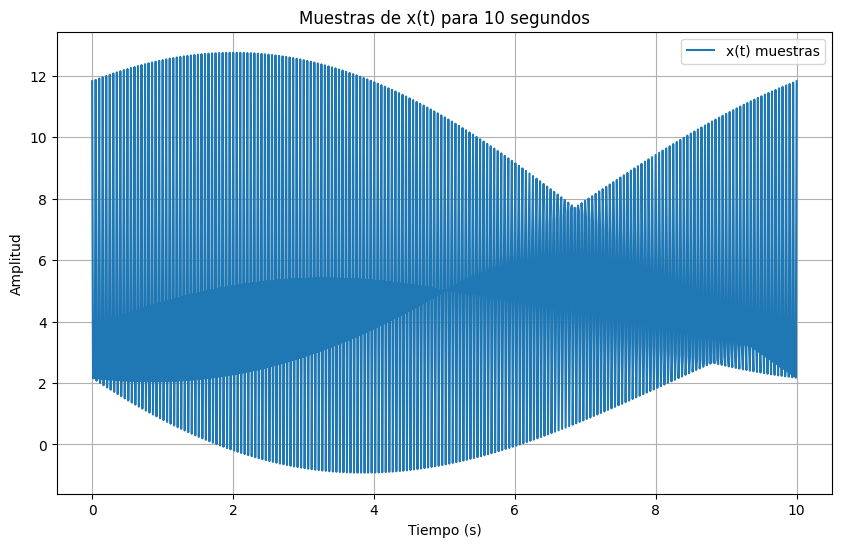

In [12]:
# Parámetros
fs = 80  # Frecuencia de muestreo (hz)
t = 10  # Duración en segundos
t_1 = np.linspace(0, t, int(fs * t))  # Tiempo muestreado

# x(t)
x= 4 * np.sin(80 * np.pi * t_1 + np.pi / 4) + 4 * np.cos(40 * np.pi * t_1) + 5

# Graficamos las muestras
plt.figure(figsize=(10, 6))
plt.plot(t_1, x, label="x(t) muestras")
plt.title("Muestras de x(t) para 10 segundos")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()
plt.show()


Punto 5.

A)

In [19]:
# Parámetros para el periodograma
M = 40  # Tamaño del segmento
S = 25  # Solapamiento entre segmentos
window = np.hanning(M)  # Ventana de Hann


# Función para dividir la señal en segmentos
def segment_signal(x, M, S):
    segments = []
    for start in range(0, len(x) - M + 1, M - S):
        segment = x[start:start + M]
        segments.append(segment)
    return np.array(segments)

b) Por cada segmento multiplicar la ventana y se calcula la transformada de fourier

In [16]:
# Periodograma
def compute_periodogram(segments, window):
    periodograms = []
    for segment in segments:
        segment_windowed = segment * window
        fft_segment = np.fft.fft(segment_windowed, n=M)
        psd = (np.abs(fft_segment) ** 2) / (M * np.sum(window ** 2))
        periodograms.append(psd)
    return np.array(periodograms)


In [17]:
# Promedio de periodogramas
def welch_periodogram(x, M, S, window):
    segments = segment_signal(x, M, S)
    periodograms = compute_periodogram(segments, window)
    avg_psd = np.mean(periodograms, axis=0)
    freqs = np.fft.fftfreq(M, 1 / fs). #Transformada de fourier
    return freqs[:M // 2], avg_psd[:M // 2]


Funcionamiento

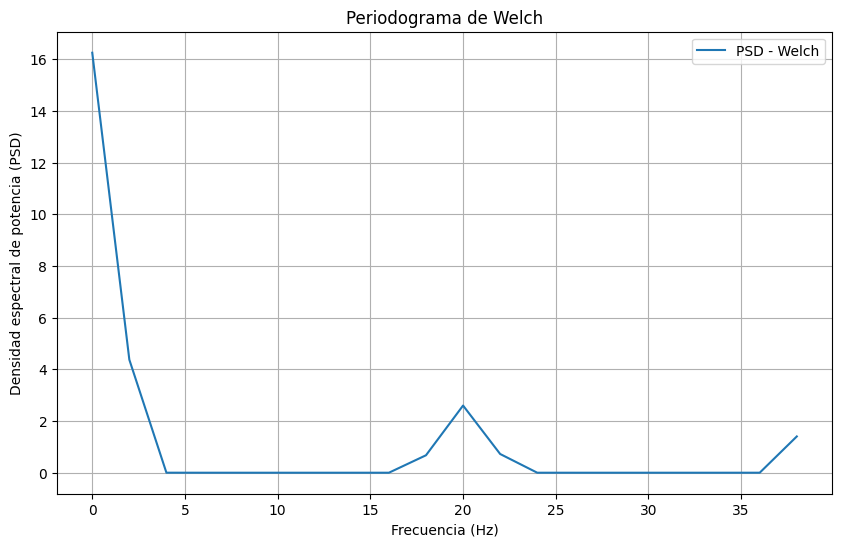

In [18]:
segments = segment_signal(x, M, S)
freqs, psd = welch_periodogram(x, M, S, window)

# Graficar el periodograma de Welch
plt.figure(figsize=(10, 6))
plt.plot(freqs, psd, label="PSD - Welch")
plt.title("Periodograma de Welch")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Densidad espectral de potencia (PSD)")
plt.grid()
plt.legend()
plt.show()

6. Punto de validacion


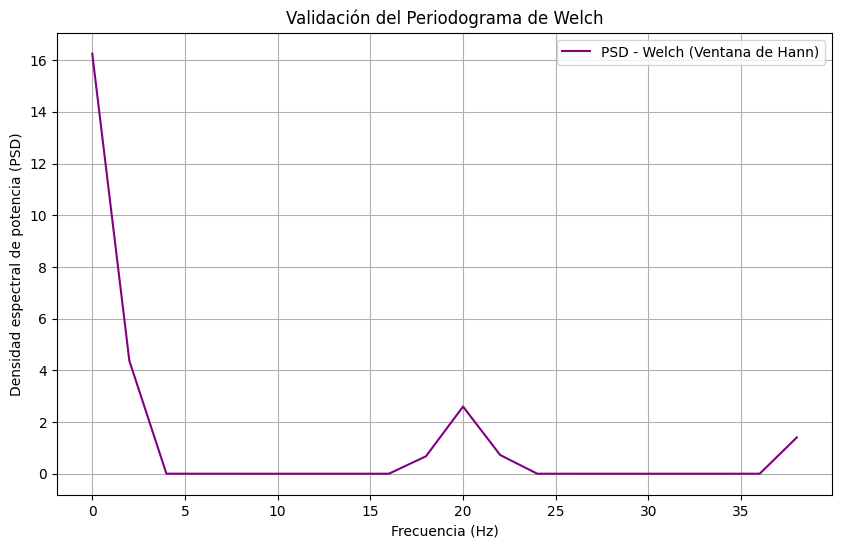

In [22]:
# Validación del periodograma de Welch
# Parámetros específicos grupo de Juan Pablo
M = 40  # Tamaño del segmento
S = 25  # Solapamiento
window = np.hanning(M)  # Ventana de Hann

# Peridiograma
freqs, psd = welch_periodogram(x, M, S, window)

# Grafica
plt.figure(figsize=(10, 6))
plt.plot(freqs, psd, label="PSD - Welch (Ventana de Hann)", color="purple")
plt.title("Validación del Periodograma de Welch")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Densidad espectral de potencia (PSD)")
plt.grid()
plt.legend()
plt.show()


Punto 7.


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import firwin, freqz

# Frecuencia de muestreo
fs = 100  # Hz
nyquist = fs / 2  # Frecuencia de Nyquist

Segun lo especificado en el link usamos signal.firwin y el numero de coeficientes correspondiente

Filtro pasa altas
* Frecuencia de corte a =10
* banda de rechazo 20 db porque nos piden al menos 10 veces menor que la amplitud de entrada
* se tuvo encuenta el link para calcular el numero de coeficientes, pero uno muy bajo seria poco preciso

In [55]:
# Filtro pasa-altas
cutoff_high = 10 / nyquist  # Normalización de la frecuencia de corte
numtaps_high = 51  # Número de coeficientes del filtro
highpass_filter = signal.firwin(numtaps_high, cutoff_high, pass_zero=False)
freq, response = signal.freqz(highpass_filter, worN=8000, fs=fs)



Filtro Pasa Bajas

* 40 dB de atenuación ya que nos piden 100 veces mas
* La frecuencia de corte es b=55 pero en este filtro no es posible usarla ya que esta frecuencia es menor a la frecuencia nyquist.

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz

# Frecuencia de muestreo
fs = 100  # Hz
nyquist = fs / 2  # Frecuencia de Nyquist

# Frecuencia de corte para el filtro pasa-bajas
cutoff_low = 45 / nyquist  # Normalización de la frecuencia de corte
numtaps_low = 10  # Número de coeficientes del filtro

# Diseñar el filtro pasa-bajas usando firwin
lowpass_filter = signal.firwin(numtaps_low, cutoff_low)

# Frecuencias y respuestas de los filtros
freq_low, response_low = freqz(lowpass_filter, worN=8000, fs=fs)





Graficar diagrama de magnitud y fase (10%)

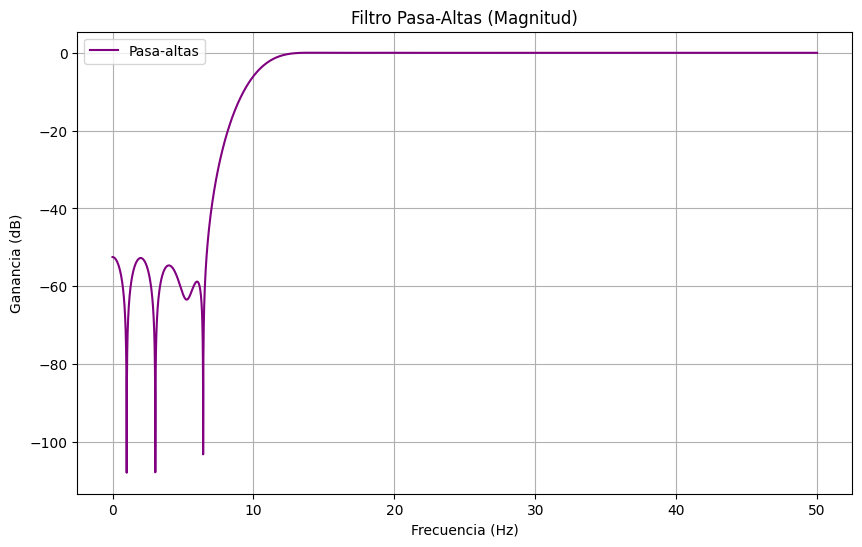

In [54]:
# Grafica PASA Altas
plt.figure(figsize=(10, 6))
plt.plot(freq, 20 * np.log10(abs(response)), label="Pasa-altas", color="purple")
plt.title("Filtro Pasa-Altas (Magnitud)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Ganancia (dB)")
plt.grid(True)
plt.legend()
plt.show()

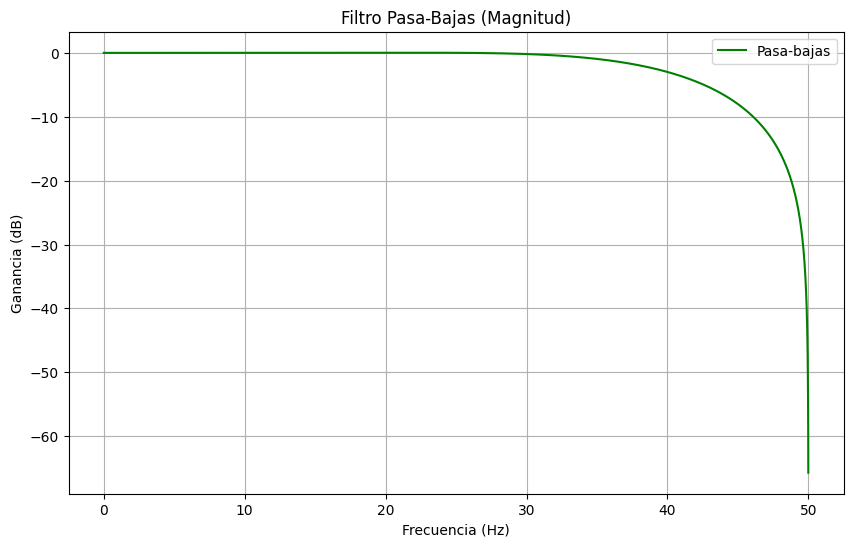

In [58]:
# Grafica el filtro pasa-bajas
plt.figure(figsize=(10, 6))
plt.plot(freq_low, 20 * np.log10(abs(response_low)), label="Pasa-bajas", color="green")
plt.title("Filtro Pasa-Bajas (Magnitud)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Ganancia (dB)")
plt.grid()
plt.legend()
plt.show()